In [ ]:
from stabilizers import *
from matplotlib import pyplot as plt
from time import time
import numpy as np
import pickle

In [ ]:
# Create random cliffords
from qiskit.quantum_info import random_clifford
from random import random

In [ ]:
def max_inner_ind(tn):
    max_size = 0
    inds = tn.inner_inds()
    for ind in inds:
        new_size = tn.ind_size(ind)
        if new_size >= max_size: 
            max_size = new_size
    return max_size

# Depth Test

Data generated by running "stabilizer_exp_heur3.py" script (Note: it can be slightly computationally expensive to do so!). It is random so a new data set will not exactly fit the existing file

In [ ]:
load = True

In [ ]:
max_sweeps_list = [1,2,3,4,5]
n_qubits = 10
total_depth = 2*n_qubits
tries = 50
mode = 'tn'
max_bond = None # this should work for not limiting max_bond

if load:
    with open("data/depth_exp.pickle", 'rb') as handle:
        samples_list = pickle.load(handle)
else:
    fig = plt.figure(figsize=(7.5,5))
    ax1 = plt.gca()
    samples_list = []
    for max_sweeps in max_sweeps_list:
        # Big non-stabilizer test
        average2 = [0,]*total_depth
        average2_bonds = [0,]*total_depth
        samples2 = []
        samples2_bonds = []

        for j in range(tries):
            bonds_dis = [1]
            ent_dis = [0]
            new_cliff = random_clifford(n_qubits)
            stn_dis = gen_clifford(new_cliff,mode=mode,max_bond=max_bond,max_sweeps=max_sweeps,disentangle='exact+heuristic')
            qc = QuantumCircuit(n_qubits)
            qc.t(int(n_qubits*random()))

            for depth in range(1,total_depth):
                print(f"Calculating depth {depth}")
                            
                stn_dis.compose(qc)
                ent_dis.append(max([stn_dis.xvec.entropy(k) for k in range(1,n_qubits)]))
                bonds_dis.append(max_inner_ind(stn_dis.xvec))

                new_cliff = random_clifford(n_qubits)
                stn_dis.compose(new_cliff)

            average2_bonds = [average2_bonds[i] + bonds_dis[i]/tries for i in range(total_depth)] 
            average2 = [average2[i] + ent_dis[i]/tries for i in range(total_depth)] 
            samples2_bonds.append(bonds_dis)
            samples2.append(ent_dis)
            
        samples_list.append(samples2)
            
        ax1.plot(range(0,total_depth),average2,label=f"depth={max_sweeps}")
        # ax1.plot(range(0,total_depth),bonds_dis,color='r',label='depth')
        # ax1.set_yscale('log')
        # ax1.set_xscale('log')
        # ax1.set_xlim([0,reference_bond]) 

    ax1.legend()

    with open("data/paper_update/depth_exp.pickle", 'wb') as handle:
            pickle.dump(samples_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

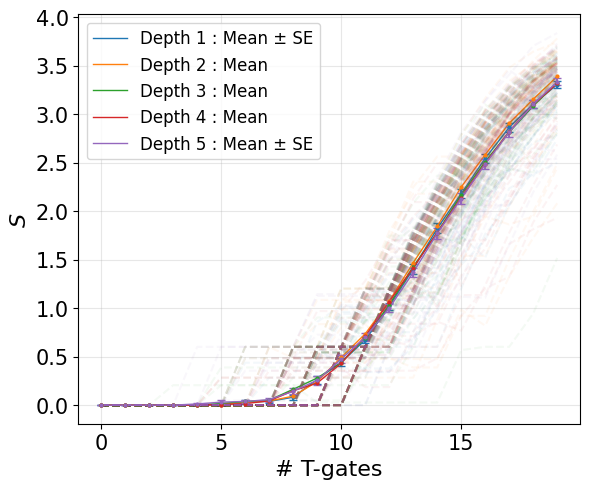

In [ ]:
x = range(0,total_depth)
alpha = 0.05

# ---------------------------------------------------------
# Plot with error bars
# ---------------------------------------------------------
# plt.figure(figsize=(5,4))
fig, ax = plt.subplots(figsize=(6,5))
for i,samples in enumerate(samples_list):
    mean_vals = np.mean(samples, axis=0)
    sigma_vals = np.std(samples, axis=0)/np.sqrt(len(samples))
    if i+1 in [1,5]:
        chosen_label = f"Depth {i+1} : Mean ± SE"
        error_size = sigma_vals
        capsize = 3
    else: 
        chosen_label = f"Depth {i+1} : Mean"
        error_size = 0
        capsize = 0
    
    err = plt.errorbar(
        x,
        mean_vals,
        yerr=error_size,
        fmt='o',
        markersize=2,
        capsize=capsize,
        # label=chosen_label
    )
    color = err[0].get_color()
    for v_raw in samples:
        ax.plot(x, v_raw[:total_depth], alpha = alpha, color=color, linestyle='dashed')
    plt.plot(x, mean_vals, linewidth=1, color=color, label=chosen_label)

size = 16

plt.xlabel("# T-gates",fontsize=size)
plt.ylabel("$S$",fontsize=size)
ax.tick_params(axis='both',labelsize=size-1)
# plt.title("Entropy of state after heuristic entanglement cooling")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=size-4)
# ax1.legend()
plt.tight_layout()                                                                                                                        
plt.savefig('sweep_depth_experiment_v4.pdf', transparent=True)
plt.show()

# Cliff-2 vs Cliff-3 heuristic

In [ ]:
import pickle
import os
import pathlib

def join_heur_data(name,dir='data/'):
    if len(name)<1:
        print('Enter file names as a non-empty array!')
        return 

    # By convention we save them in \\data\\ so that is the default directory to search
    path = str(pathlib.Path().resolve()) + '\\' + str(pathlib.Path(dir))
    # Check if we already joined trainings into a saved full training
    file_ls = [dir+str(i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and name in i]
    if len(file_ls)<1:
        print('No files with this name were found! You should include the full path to their directory if you did not.')
        return 

    with open(file_ls[0], 'rb') as handle:
        data = pickle.load(handle)
        min_len = len(data['samples'][0])

    if len(file_ls)>1:
        for name in file_ls[1:]:
            with open(name, 'rb') as handle:
                entry = pickle.load(handle)
                if len(entry['samples'][0])<min_len:
                    min_len = len(entry['samples'][0])
            prev_len = len(data['samples'])
            data['samples'] += entry['samples']
            new_len = len(data['samples'])
            for i in range(min_len):
                data['average'][i] = data['average'][i] * prev_len/new_len + entry['average'][i] * len(entry['samples'])/new_len
            

    return data

In [ ]:
data_2 = join_heur_data('heur2',dir='data//')
samples2 = data_2['samples']
average2 = data_2['average']
total_depth = len(average2)

data_3 = join_heur_data('heur3',dir='data/')
samples3 = data_3['samples']
average3 = data_3['average']
test = len(average3)

if total_depth!=test:
    print('depths between heur2 and heur3 do not match!')

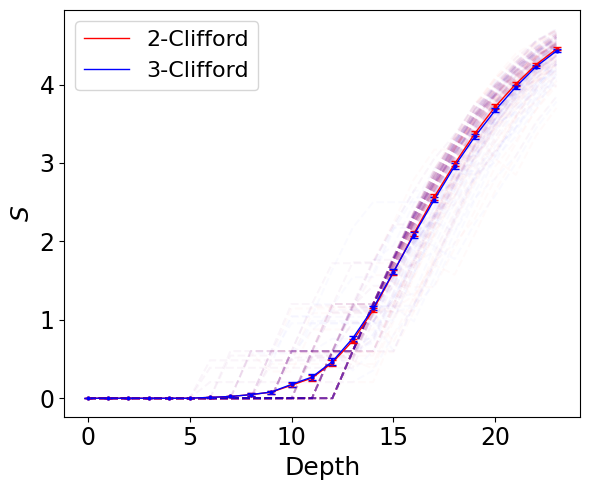

In [ ]:
fig = plt.figure(figsize=(6,5))  # figsize=(12,5)
ax = fig.add_subplot(111)
total_depth = len(average3)
alpha = 0.02
size = 18

mean_vals2 = np.mean(samples2, axis=0)
sigma_vals2 = np.std(samples2, axis=0)/np.sqrt(len(samples2))
mean_vals3 = np.mean(samples3, axis=0)
sigma_vals3 = np.std(samples3, axis=0)/np.sqrt(len(samples3))
chosen_label = '2-Clifford heuristic'

x = range(0,total_depth)

for v_raw in samples2:
	ax.plot(x, v_raw[:total_depth], alpha = alpha, color='r', linestyle='dashed')
for v_raw in samples3:
	ax.plot(x, v_raw[:total_depth], alpha = alpha, color='b', linestyle='dashed')

chosen_label = '2-Clifford'
ax.errorbar(
    x,
    mean_vals2,
    yerr=sigma_vals2,
    fmt='o',
    markersize=2,
    capsize=3,
    # label=chosen_label,
    color = 'r'
)
# color = err[0].get_color()
plt.plot(x, mean_vals2, linewidth=1, color='r', label=chosen_label)
# ax.semilogy(x, mean_vals2[:total_depth], label="Cliff 2", alpha = 1, color='r',) # linestyle=linestyles[0]['compact' in label])

chosen_label = '3-Clifford'
err = plt.errorbar(
    x,
    mean_vals3,
    yerr=sigma_vals3,
    fmt='o',
    markersize=2,
    capsize=3,
    # label=chosen_label,
    color='b'
)
# color = err[0].get_color()
plt.plot(x, mean_vals3, linewidth=1, color='b', label=chosen_label)
# ax.semilogy(x, mean_vals3[:total_depth], label="Cliff 3", alpha = 1, color='b',) # linestyle=linestyles[0]['compact' in label])
# if disp_best:
	# ax.semilogy(range(0,total_depth), best, label=f"best", alpha = 1, color='c',) # linestyle=linestyles[1]['compact' in label])

plt.ylabel("$S$",fontsize=size)
plt.xlabel("Depth",fontsize=size)
ax.tick_params(axis='both',labelsize=size-1)
# ax1.set_yscale('log')
# ax1.set_xscale('log')
# ax1.set_xlim([0,reference_bond]) 

# plt.xlim(-10,1080)
# plt.xticks(fontsize=15)
# plt.ylim(2*10**-7, 2)
# plt.yticks(fontsize=15)
# plt.legend(bbox_to_anchor=(1.02, 0.9))
plt.legend(fontsize=size-2)
# plt.title(f"State encoding (n={n}, $\chi$={chis[n]['mps']})",fontsize=16)
plt.tight_layout()
# plt.savefig('training_16_full_mean.svg', transparent=True)
plt.savefig('heur2_heur3_v6.pdf', transparent=True)
plt.show()                                                                                                                         

# Rotation angle experiments

In [ ]:
import numpy as np
from scipy.special import gamma, factorial
from scipy.interpolate import make_smoothing_spline
from scipy.stats import linregress as reg
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rc
rc('text', usetex=True)

%matplotlib inline

plt.rc('font', family='serif')
plt.rcParams["figure.frameon"]
#plt.rcParams.update({'font.size': 16}) 
plt.rcParams.update({'font.size': 19}) 
#plt.rcParams.update({'font.size': 8}) 

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# import pandas as pd

fig, ax1=plt.subplots(1)

mus = [-1,1,2,3,4,5,7]
colorparams = mus
colormap = cm.viridis
#colormap = cm.gnuplot2
#colormap = cm.hsv
normalize = mcolors.Normalize(vmin=0, vmax=6)


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [ ]:
import itertools
import pathlib
import pickle
import os
import numpy as np

def data_extractor(dir='data/rotations/',limit=100,disent=True):

    data_fid = {} # param: {t: [0,]*samples for t in t_gate_fid_points[N]} for param in params}
    data_local = {}
    data_bonds = {}
    data_entropy = {} # param: [0,]*(t_gates[N]) for param in params}
    # data_entropy_rescaled ={}
    data_types = [data_fid,data_local,data_bonds,data_entropy]#,data_entropy_rescaled]
    # length_map = {}

    for L in [6,8,10,12,14,16,18,20,32,50,100]:
        if L>limit:
            break
        for data in data_types[:3]:
            data[L] = {np.float32(p) : {} for p in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]}
        for data in data_types[3:]:
            data[L] = {np.float32(p) : [] for p in  [0.01,0.1,0.2,0.4,0.6,0.8,1.0]}
        # if L<=32:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['']
        # elif L==50:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['p1','p2','p3a','p3b','p3c']
        # elif L==100:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['p1','p2a','p2b','p2c','p3a','p3b','p3c'] # Actually p3c is not completed
        if L<16:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['']
        elif L==16:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['p1','p2','p3']
        elif L>16:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['p1','p2a','p2b','p2c','p3a','p3b','p3c'] # Actually p3c is not completed

        suffixes = ['_'.join(a) for a in itertools.product(params,modifiers)]

        name = f"stabilizer_rot_trunc_{L}_"
        # print(name+suffixes[0])
        path = str(pathlib.Path().resolve()) + "\\" + str(pathlib.Path(dir))
        for suff in suffixes:
            if disent:
                file_list = [dir + str(i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and ('_'+str(L)+'.' in i or '_'+str(L)+'_' in i) and ('_'+str(suff)+'.' in i or '_'+str(suff)+'_' in i) and ('ent' not in i)]
            else:
                file_list = [dir + str(i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and ('_'+str(L)+'.' in i or '_'+str(L)+'_' in i) and ('_'+str(suff)+'.' in i or '_'+str(suff)+'_' in i) and ('ent' in i)]
            # length_map[L]=len([t for t in file_list])
            repeats = len([t for t in file_list]) # assume we repeat the same amount of times for each parameter (by 12/10/25 we do via the experiment)
            # print(repeats)
            # print(file_list)
            # repeats = 1
            # for name in file_list[0:1]:
            for name in file_list:
                with open(name, 'rb') as handle:
                    entry = pickle.load(handle)

                # print([p for p in entry[3]])
                # print([p for p in entry[0]])
                
                par = [h for h in entry[0]][0]
                for data in data_types[:3]:
                    for p in data[L]:
                        if len(data[L][p])==0:
                            data[L][p] = {t: np.array([0.,]*len(entry[0][par][t])) for t in entry[0][par]}
                for data in data_types[3:]:
                    for p in data[L]:
                        if len(data[L][p])==0:
                            data[L][p] = np.array([0.,]*len(entry[3][par]))

                # print(len(data_types[3][L][np.float32(0.1)]))
                for param in entry[0]:
                    # if name=='data/rotations/stabilizer_rot_trunc_50_1.0_p3c.pickle':
                    # if name=='data/rotations/stabilizer_rot_trunc_10_0.01_.pickle':
                        # print(entry[3][param])
                    for i,data in enumerate(data_types):
                        if i<2:
                            for t in entry[i][param]:
                                try:
                                    data[L][np.float32(param)][t] += [np.float32(k/repeats) for k in entry[i][param][t]]
                                except ValueError:
                                    data[L][np.float32(param)][t] = data[L][np.float32(param)][t][:len(entry[i][param][t])]
                                    data[L][np.float32(param)][t] += [np.float32(k/repeats) for k in entry[i][param][t][:len(data[L][np.float32(param)][t])]]
                        elif i==2:
                            for t in entry[i][param]:
                                try:
                                    data[L][np.float32(param)][t] += [k for k in entry[i][param][t]]
                                except ValueError:
                                    data[L][np.float32(param)][t] = data[L][np.float32(param)][t][:len(entry[i][param][t])]
                                    data[L][np.float32(param)][t] += [k for k in entry[i][param][t][:len(data[L][np.float32(param)][t])]]
                        else:
                            if entry[i][param] != [0,]:
                                # print(f"hey i'm doing something with {name}")
                                try:
                                    data[L][np.float32(param)] += [np.float32(k/repeats) for k in entry[i][param]]
                                except ValueError:
                                    data[L][np.float32(param)] = data[L][np.float32(param)][:len(entry[i][param])]
                                    data[L][np.float32(param)] += [np.float32(k/repeats) for k in entry[i][param][:len(data[L][np.float32(param)])]]
                                # print(len(data[L][np.float32(param)]))
                            # else:
                            #     print('skipped')

    return data_types

In [ ]:
data_fid, data_local, data_bonds, data_entropy = data_extractor(dir='data/rotation/')
data_fid_ent, data_local_ent, data_bonds_ent, data_entropy_ent = data_extractor(dir='data/rotation_entangled/',disent=False)
save = False

C:\Users\sergi\AppData\Local\Temp\ipykernel_35312\83178903.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  data[L][np.float32(param)][t] += [np.float32(k/repeats) for k in entry[i][param][t]]
C:\Users\sergi\AppData\Local\Temp\ipykernel_35312\83178903.py:88: ComplexWarning: Casting complex values to real discards the imaginary part
  data[L][np.float32(param)][t] += [np.float32(k/repeats) for k in entry[i][param][t][:len(data[L][np.float32(param)][t])]]


## Entropies


In [ ]:
if (len(data_entropy[20][np.float32(0.6)])-1)/(96+1) > 1: # gives 17 if data is duplicated
    correct = True
else:
    correct = False
print((len(data_entropy[20][np.float32(0.6)])-1)/(96+1))

-0.010309278350515464


In [ ]:
bond_dim = 128
n_bond_dim = int(np.log2(bond_dim))
samples = 20
bond_list_pre = list(set([int(d) for d in np.logspace(0,n_bond_dim,base=2,num=samples)]))
bond_list_pre.sort()
bond_list = bond_list_pre
if correct:
    correction = len(bond_list)+1
else: 
    correction = 1

In [ ]:
save = False

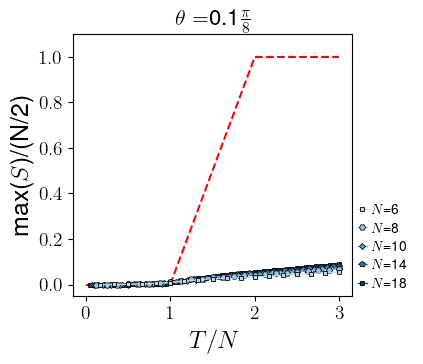

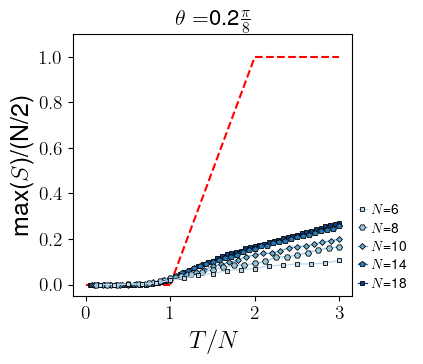

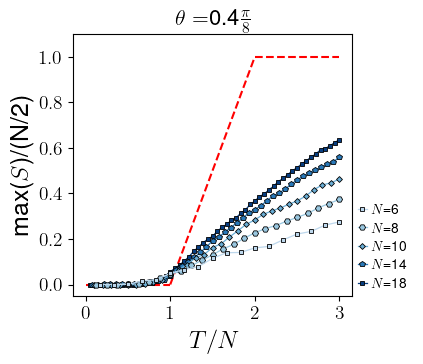

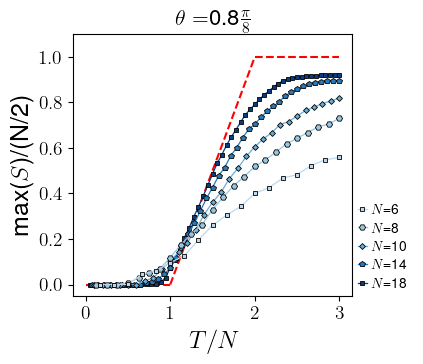

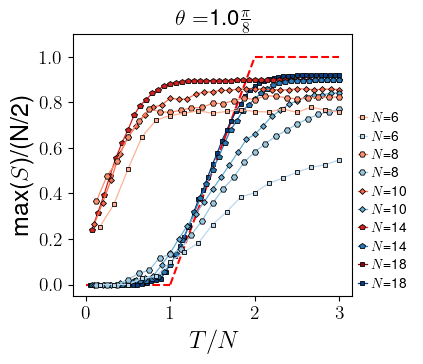

In [ ]:
parameters = [0.1,0.2,0.4,0.8,1.0]
Ls = [6,8,10,14,18]#,20,32,50,100]
data = data_entropy
data_en = data_entropy_ent

plt.rcParams.update({'font.size': 14}) 

slope_y = {L: [] for L in Ls}
slope_x = []
        
for FF in parameters:
    
    fig,ax1=plt.subplots()
    
    csize=3
    msize=4
    lwi=1.1
    iw=0
    
    
    sty=['H','D','p','s-','o-','H-','D-','p-','s-']
    msi = [4,3,4,3,3,3,3,2,3,2,2,]  
    iw=0
    
    
    LWI=0.9
    MSI=3
    
    sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
    msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
    iw=0
    
    slope_x.append(np.float32(FF))
    
    for L in Ls: #[32,64,128,256,512,1024,2048,4096]:
        if L not in data and L not in data_en:
            print(f"There is no data for length {L} and parameter {FF}")
            continue
        if FF==1.0:
            data_set = [data_en[L][np.float32(FF)],data[L][np.float32(FF)]]
        else:
            data_set = [data[L][np.float32(FF)]]
        for i,d in enumerate(data_set):
            xtab = []
            ytab = []
            # d = data[L][np.float32(FF)]
            # length = len(d)
            d_fix = d
            # d_fix = d[length-length//correction:]
            for r in range(1,min(len(d_fix), 1005) ): 
                xtab.append(r)
                ytab.append(d_fix[r])
                if mark==0 and d_fix[r] > 0:
                    mark = r
        
            ytab= np.array(ytab)
            xtab= np.array(xtab)
            SAT = L-(2*L-1)*L/(2**L+1)
            #print(SAT, ytab[L-2])
            if i==0 and FF==1.0:
                colormap = cm.Reds
            else:
                colormap = cm.Blues
            normalize = mcolors.Normalize(vmin=1, vmax=19)
            CLR=colormap( normalize(  L ) )
            # plt.plot(xtab/L, ytab/min(L/2,7) ,sty[iw], color=CLR,markersize=msi[iw],
            plt.plot(xtab/L, ytab*2/L ,sty[iw], color=CLR,markersize=msi[iw],
                        markeredgewidth=.6, markeredgecolor='black', label='$N$='+str(L),
                        linewidth=LWI, zorder=100-iw)
        iw+=1
        mark1 = L
        mark2 = 2*L
        if len(ytab)>0:
            # slope_y[L].append(reg(xtab[mark1:mark2],ytab[mark1:mark2]/min(L/2,7)).slope)
            slope_y[L].append(reg(xtab[mark1:mark2]/L,ytab[mark1:mark2]/(L/2)).slope)
        
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    axes.set_ylim([-0.05,1.1])
    #plt.yscale('log')
    #plt.xscale('log')
    plt.title(r'$\theta =$' +str(FF) +r'$ \frac{\pi}{8}$', fontsize=16)
    
    plt.plot([0,1],[0,0],'--', color='red')
    plt.plot([1,2],[0,1],'--', color='red')
    plt.plot([2,3],[1,1],'--', color='red')
    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=10,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$ T/N$",fontsize=18)
    plt.ylabel(r"max($S$)/(N/2)",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    plt.show()
    if save:
        fig.savefig("plots/"+str(FF)+"entropy_resc_v2.pdf", bbox_inches='tight', transparent=True)

plt.show()

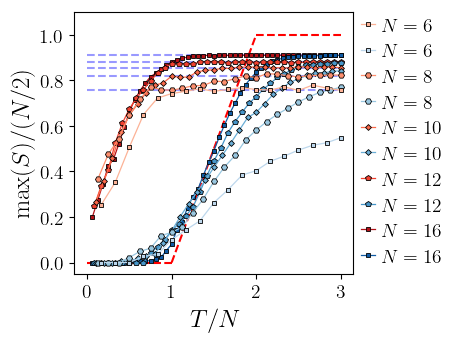

In [ ]:
lines = {6: 0.759550826518506 , 8: 0.8196631198888795 , 10: 0.8557304959111036 , 12: 0.8799473759668706, 14: 0.8969503542222169, 16: 0.9098315599444398, 18: 0.9198502755061687,}

parameters = [1.0]
Ls = [6,8,10,12,16]
data = data_entropy
data_en = data_entropy_ent

plt.rcParams.update({'font.size': 14}) 

slope_y = {L: [] for L in Ls}
slope_x = []
        
for FF in parameters:
    
    fig,ax1=plt.subplots()
    
    csize=3
    msize=4
    lwi=1.1
    iw=0
    
    
    sty=['H','D','p','s-','o-','H-','D-','p-','s-']
    msi = [4,3,4,3,3,3,3,2,3,2,2,]  
    iw=0
    
    
    LWI=0.9
    MSI=3
    
    sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
    msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
    iw=0
    
    slope_x.append(np.float32(FF))
    
    for L in Ls: #[32,64,128,256,512,1024,2048,4096]:
        if L not in data and L not in data_en:
            print(f"There is no data for length {L} and parameter {FF}")
            continue
        if FF==1.0:
            data_set = [data_en[L][np.float32(FF)],data[L][np.float32(FF)]]
        else:
            data_set = [data[L][np.float32(FF)]]
        for i,d in enumerate(data_set):
            xtab = []
            ytab = []
            # d = data[L][np.float32(FF)]
            # length = len(d)
            d_fix = d
            # d_fix = d[length-length//correction:]
            for r in range(1,min(len(d_fix), 1005) ): 
                xtab.append(r)
                ytab.append(d_fix[r])
                if mark==0 and d_fix[r] > 0:
                    mark = r
        
            ytab= np.array(ytab)
            xtab= np.array(xtab)
            SAT = L-(2*L-1)*L/(2**L+1)
            #print(SAT, ytab[L-2])
            if i==0 and FF==1.0:
                colormap = cm.Reds
            else:
                colormap = cm.Blues
            normalize = mcolors.Normalize(vmin=1, vmax=19)
            CLR=colormap( normalize(  L ) )
            # plt.plot(xtab/L, ytab/min(L/2,7) ,sty[iw], color=CLR,markersize=msi[iw],
            plt.plot(xtab/L, ytab*2/L ,sty[iw], color=CLR,markersize=msi[iw],
                        markeredgewidth=.6, markeredgecolor='black', label=f"$N={str(L)}$",
                        linewidth=LWI, zorder=100-iw)
        iw+=1
        mark1 = L
        mark2 = 2*L
        if len(ytab)>0:
            # slope_y[L].append(reg(xtab[mark1:mark2],ytab[mark1:mark2]/min(L/2,7)).slope)
            slope_y[L].append(reg(xtab[mark1:mark2]/L,ytab[mark1:mark2]/(L/2)).slope)
        
        plt.plot([0,3],[lines[L],lines[L]],'--', color='blue', alpha = 0.4)
        
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    axes.set_ylim([-0.05,1.1])
    #plt.yscale('log')
    #plt.xscale('log')
    # plt.title(f"$\theta={str(FF)}$"+r"$\frac{\pi}{8}$", fontsize=16)
    
    plt.plot([0,1],[0,0],'--', color='red')
    plt.plot([1,2],[0,1],'--', color='red')
    plt.plot([2,3],[1,1],'--', color='red')
    
    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=14,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$ T/N$",fontsize=18)
    plt.ylabel(r"$\max (S)/(N/2)$",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    plt.show()
    if save:
        fig.savefig("plots/"+str(FF)+"entropy_resc_v3.pdf", bbox_inches='tight', transparent=True)

plt.show()

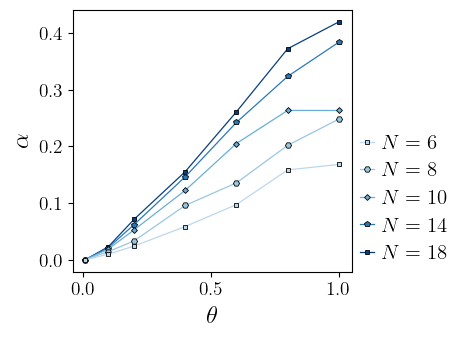

In [ ]:
parameters = [0.1,0.2,0.4,0.8,1.0]
Ls = [6,8,10,14,18]#,20,32,50,100]
data = data_entropy

plt.rcParams.update({'font.size': 14}) 

fig,ax1=plt.subplots()

csize=3
msize=4
lwi=1.1
iw=0


sty=['H','D','p','s-','o-','H-','D-','p-','s-']
msi = [4,3,4,3,3,3,3,2,3,2,2,]  
iw=0


LWI=0.9
MSI=3

sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
iw=0

for L in Ls:
    SAT = L-(2*L-1)*L/(2**L+1)
    #print(SAT, ytab[L-2])
    colormap = cm.Blues
    normalize = mcolors.Normalize(vmin=1, vmax=19)
    CLR=colormap( normalize(  L ) )
    plt.plot(slope_x,slope_y[L],sty[iw], color=CLR,markersize=msi[iw],
                markeredgewidth=.6, markeredgecolor='black', label=f"$N={str(L)}$",
                linewidth=LWI, zorder=100-iw)
    iw+=1

axes=plt.gca()
#axes.set_xlim([1.7,2e4])
#axes.set_ylim([4e-4,0.9e4])
#plt.yscale('log')
#plt.xscale('log')
# plt.title(r'$\theta =$' +str(FF) +r'$ \frac{\pi}{8}$', fontsize=16)


#xs=np.linspace(0,100,100)
#plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
#plt.plot(xs, xs*0+np.log(2),'--', color='black')
plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=15,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)

#axes.set_yticks([0.38,0.43,0.48,0.53])
#plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
#axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
#axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
#plt.locator_params(axis='x', nbins=12)
#plt.grid()

plt.xlabel(r"$\theta$",fontsize=18)
plt.ylabel(r"$\alpha$",fontsize=18)

fig.set_size_inches(3.6,3.4, forward=True)   
if save:
    fig.savefig("plots/"+str(FF)+"entropy_rescaled_slope_v3.pdf", bbox_inches='tight',transparent=True)

plt.show()
    

## Fidelities

Data generated with the script stabilizer_exp_large_rotations (or stabilizer_exp_large_rotations to avoid using the disentangler for the "red" lines in the plot)

In [ ]:
import itertools
import pathlib
import pickle
import os
import numpy as np

def data_extractor_fids(dir='data/rotations/',limit=100,N=None,disent=True):

    data_fid = {} # param: {t: [0,]*samples for t in t_gate_fid_points[N]} for param in params}
    data_local = {}
    data_bonds = {}
    data_entropy = {} # param: [0,]*(t_gates[N]) for param in params}
    # data_entropy_rescaled ={}
    data_types = [data_fid,data_local,data_bonds,data_entropy]#,data_entropy_rescaled]
    # length_map = {}
    if N is None:
        Ls = [6,8,10,12,14,16,18,20,32,50,100]
    else:
        Ls = [N]

    for L in Ls:
        if L>limit:
            break
        for data in data_types[:3]:
            data[L] = {np.float32(p) : {} for p in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]}
        for data in data_types[3:]:
            data[L] = {np.float32(p) : [] for p in  [0.01,0.1,0.2,0.4,0.6,0.8,1.0]}
        if L<32:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['']
        elif L==100:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['p1','p2a','p2b','p2c','p3a','p3b','p3c'] # Actually p3c is not completed
        else:
            params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
            modifiers = ['p1','p2','p3a','p3b','p3c']
        
        # if L<16:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['']
        # elif L==16:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['p1','p2','p3']
        # elif L>16:
        #     params = [str(b) for b in [0.01,0.1,0.2,0.4,0.6,0.8,1.0]]
        #     modifiers = ['p1','p2a','p2b','p2c','p3a','p3b','p3c'] # Actually p3c is not completed

        suffixes = ['_'.join(a) for a in itertools.product(params,modifiers)]

        name = f"stabilizer_rot_trunc_{L}_"
        # print(name+suffixes[0])
        path = str(pathlib.Path().resolve()) + "\\" + str(pathlib.Path(dir))
        # print(params)
        done_suffs = {np.float32(p): [] for p in params}
        len_suffs = {np.float32(p): [0,] for p in params}
        done_suffs_strict = {np.float32(p): [] for p in params}
        for suff in suffixes:
            # print(suff)
            if disent:
                file_list = [dir + str(i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and ('_'+str(L)+'.' in i or '_'+str(L)+'_' in i) and ('_'+str(suff)+'.' in i or '_'+str(suff)+'_' in i) and ('ent' not in i)]
            else:
                file_list = [dir + str(i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and ('_'+str(L)+'.' in i or '_'+str(L)+'_' in i) and ('_'+str(suff)+'.' in i or '_'+str(suff)+'_' in i) and ('ent' in i)]
            # length_map[L]=len([t for t in file_list])
            repeats = len([t for t in file_list]) # assume we repeat the same amount of times for each parameter (by 12/10/25 we do via the experiment)
            # print(repeats)
            print(file_list)
            # repeats = 1
            # for name in file_list[0:1]:
            for name in file_list:
                print(name)
                with open(name, 'rb') as handle:
                    entry = pickle.load(handle)

                # print([p for p in entry[3]])
                # print([p for p in entry[0]])
                
                par = [h for h in entry[0]][0]
                for data in data_types[:1]:
                    for p in entry[0]:
                        # print(p)
                        # print(done_suffs_strict)
                        len_suff = len(entry[0][par][[t for t in entry[0][par]][0]])
                        if len(data[L][p])==0:
                            # print(f"I initialized with {len_suff}")
                            data[L][p] = {t: np.array([0.,]*len_suff) for t in entry[0][par]}
                        elif suff not in done_suffs_strict[p]:
                            # print(len_suff)
                            # print(f"I extended by {len_suff}")
                            for t in data[L][p]:
                                data[L][p][t] = np.concatenate((data[L][p][t],np.array([0.,]*len_suff)))
                            # print(len(data[L][p][t]))
                for data in data_types[2:3]:
                    for p in data[L]:
                        if len(data[L][p])==0:
                            data[L][p] = {t: [] for t in entry[0][par]}
                # for data in data_types[3:]:
                #     for p in data[L]:
                #         if len(data[L][p])==0:
                #             try:
                #                 data[L][p] = np.array([0.,]*len(entry[3][par]))
                #                 flag = True
                #             except TypeError:
                #                 flag = False
                #                 data[L][p] = np.array(entry[3])

                # print(len(data_types[3][L][np.float32(0.1)]))
                print(entry[0])
                for param in entry[0]:
                    # if name=='data/rotations/stabilizer_rot_trunc_50_1.0_p3c.pickle':
                    # if name=='data/rotations/stabilizer_rot_trunc_10_0.01_.pickle':
                        # print(entry[3][param])
                    for i,data in enumerate(data_types):
                        if i<1:
                            for t in entry[i][param]:
                                try:
                                    data[L][np.float32(param)][t][sum(len_suffs[param]):sum(len_suffs[param]) + len_suff] += [np.float32(k/repeats) for k in entry[i][param][t]]
                                except ValueError:
                                    data[L][np.float32(param)][t] = data[L][np.float32(param)][t][:len(entry[i][param][t])]
                                    data[L][np.float32(param)][t][sum(len_suffs[param]):sum(len_suffs[param]) + len_suff] += [np.float32(k/repeats) for k in entry[i][param][t][:len(data[L][np.float32(param)][t])]]
                        elif i==2:
                            for t in entry[i][param]:
                                if suff not in done_suffs_strict[param]:
                                    try:
                                        data[L][np.float32(param)][t] += [k for k in entry[i][param][t]]
                                    except ValueError:
                                        print('error')
                                        data[L][np.float32(param)][t] = data[L][np.float32(param)][t][:len(entry[i][param][t])]
                                        data[L][np.float32(param)][t] += [k for k in entry[i][param][t][:len(data[L][np.float32(param)][t])]]
                                    done_suffs_strict[param].append(suff)
                        # else:
                        #     if flag:
                        #         if entry[i][param] != [0,]:
                        #             # print(f"hey i'm doing something with {name}")
                        #             try:
                        #                 data[L][np.float32(param)] += [np.float32(k/repeats) for k in entry[i][param]]
                        #             except ValueError:
                        #                 data[L][np.float32(param)] = data[L][np.float32(param)][:len(entry[i][param])]
                        #                 data[L][np.float32(param)] += [np.float32(k/repeats) for k in entry[i][param][:len(data[L][np.float32(param)])]]
                        #             # print(len(data[L][np.float32(param)]))
                        #         # else:
                        #         #     print('skipped')
                    
                    # print(done_suffs_strict)
                    # print(len_suffs)
            try:
                done_suffs[np.float32(param)].append(suff)
                len_suffs[np.float32(param)].append(len_suff)
            except UnboundLocalError:
                continue

    return data_types

In [ ]:
data_fid, data_local, data_bonds, data_entropy = data_extractor_fids(dir='data/rotation_fidelity/')

In [ ]:
data_fid_50, _, data_bonds_50, _ = data_extractor_fids(dir='data/rotation_entangled/',N=50)

['0.01', '0.1', '0.2', '0.4', '0.6', '0.8', '1.0']
0.01_p1
data/rotations_thesis/rot_batch_5/stabilizer_rot_trunc_50_0.01_p1_36767_712591.pickle
0.01
{0.01: [], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
I initialized with 8
{0.01: ['0.01_p1'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0], 1.0: [0]}
data/rotations_thesis/rot_batch_5/stabilizer_rot_trunc_50_0.01_p1_36770_829937.pickle
0.01
{0.01: ['0.01_p1'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: ['0.01_p1'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0], 1.0: [0]}
data/rotations_thesis/rot_batch_5/stabilizer_rot_trunc_50_0.01_p1_36773_769068.pickle
0.01
{0.01: ['0.01_p1'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: ['0.01_p1'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0], 1.0: [

C:\Users\smasot\AppData\Local\Temp\ipykernel_14520\819248048.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
  data[L][np.float32(param)][t][sum(len_suffs[param]):sum(len_suffs[param]) + len_suff] += [np.float32(k/repeats) for k in entry[i][param][t]]


0.01
{0.01: ['0.01_p1', '0.01_p2'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
1
I extended by 1
7
{0.01: ['0.01_p1', '0.01_p2', '0.01_p3a'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0, 8, 6], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0], 1.0: [0]}
data/rotations_thesis/rot_batch_5/stabilizer_rot_trunc_50_0.01_p3a_45761_926322.pickle
0.01
{0.01: ['0.01_p1', '0.01_p2', '0.01_p3a'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: ['0.01_p1', '0.01_p2', '0.01_p3a'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0, 8, 6], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0], 1.0: [0]}
data/rotations_thesis/rot_batch_5/stabilizer_rot_trunc_50_0.01_p3a_46290_471611.pickle
0.01
{0.01: ['0.01_p1', '0.01_p2', '0.01_p3a'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: ['0.01_p1', '0.01_p2', '0.01_p3a'], 0.1: [], 0.2: [], 0.4: [], 0.6: [], 0.8: [], 1.0: []}
{0.01: [0, 8, 6], 0.1: [0], 0.2: [0], 0.4: [0], 0.6: [0], 0.8: [0

In [ ]:
t_gate_fid_points = {N: [int(0.1*N), int(0.5*N), int(N), int(1.5*N), int(2*N), int(3*N)] for N in Ls}

In [ ]:
save = False

In [ ]:
data_fid_50[50][1.0][150] = np.array([0,]*len(data_fid_50[50][1.0][100]))

[1.00000001 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001]
[1, 2, 3, 4, 5, 7, 9, 12, 16, 21, 27, 35, 46, 59, 76, 99, 128]
[1.00000001 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001]
[1, 2, 3, 4, 5, 7, 9, 12, 16, 21, 27, 35, 46, 59, 76, 99, 128]
[0.90126529 0.96689632 0.99552594 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001 1.00000001]
[1, 2, 3, 4, 5, 7, 9, 12, 16, 21, 27, 35, 46, 59, 76, 99, 128]
[0.13014711 0.14407712 0.15178844 0.16139344 0.16853764 0.18491194
 0.19993157 0.21667703 0.23995903 0.26757126 0.30294083 0.31417453
 0.32355088 0.33327338 0.3457226  0.36138687 0.38027893]
[1, 2, 3, 4, 5, 7, 9, 12, 16, 21, 27, 35, 46, 5

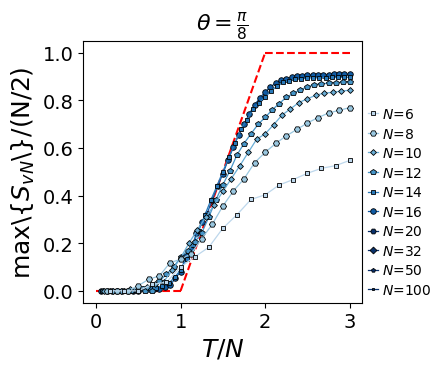

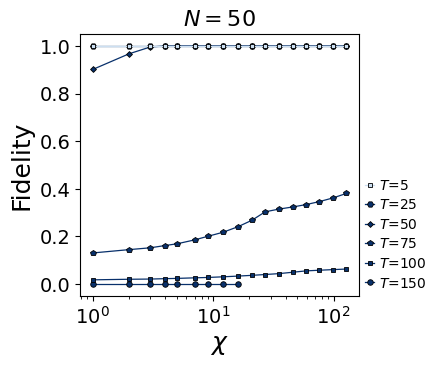

In [ ]:
FF = 1
L = 50
cutoff = 1500
data = data_fid_50
data_x = data_bonds_50
plt.rcParams.update({'font.size': 14}) 
    
fig,ax1=plt.subplots()

csize=3
msize=4
lwi=1.1
iw=0


sty=['H','D','p','s-','o-','H-','D-','p-','s-']
msi = [4,3,4,3,3,3,3,2,3,2,2,]  
iw=0


LWI=0.9
MSI=3

sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
iw=0

dat_y = data[L][np.float32(FF)]
dat_x = data_x[L][np.float32(FF)] 
for T in dat_y:
    if T>cutoff:
        continue
    dy = dat_y[T]
    dx = dat_x[5]
    print(dy)
    print(dx)
    xtab = []
    ytab = []
    for r in range(len(dy)): 
        xtab.append(dx[r])
        ytab.append(dy[r])

    ytab= np.array(ytab)
    xtab= np.array(xtab)
    SAT = L-(2*L-1)*L/(2**L+1)
    #print(SAT, ytab[L-2])
    colormap = cm.Blues
    normalize = mcolors.Normalize(vmin=1, vmax=19)
    CLR=colormap( normalize( T ) )
    plt.plot(xtab, ytab ,sty[iw], color=CLR,markersize=msi[iw],
                    markeredgewidth=.6, markeredgecolor='black', label='$T$='+str(T),
                    linewidth=LWI, zorder=100-iw)
    iw+=1
    
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    # axes.set_ylim([-0.05,1.1])

    #plt.yscale('log')
    plt.xscale('log')
    plt.title(r'$N=$' +str(L), fontsize=16)
    
    # plt.plot([0,1],[0,0],'--', color='red')
    # plt.plot([1,2],[0,1],'--', color='red')
    # plt.plot([2,3],[1,1],'--', color='red')


    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=10,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$\chi$",fontsize=18)
    plt.ylabel(r"Fidelity",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    if save:
        fig.savefig("plots/"+str(L)+"fidelities.pdf", bbox_inches='tight', transparent=True )

plt.show()

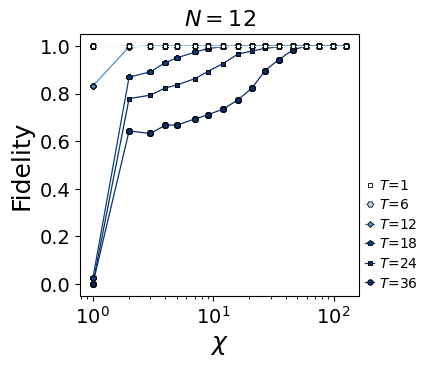

In [ ]:
FF = 1
L = 12
cutoff = 1500
data = data_fid
data_x = data_bonds
plt.rcParams.update({'font.size': 14}) 
    
fig,ax1=plt.subplots()

csize=3
msize=4
lwi=1.1
iw=0


sty=['H','D','p','s-','o-','H-','D-','p-','s-']
msi = [4,3,4,3,3,3,3,2,3,2,2,]  
iw=0


LWI=0.9
MSI=3

sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
iw=0

dat_y = data[L][np.float32(FF)]
dat_x = data_x[L][np.float32(FF)] 
for T in dat_y:
    if T>cutoff:
        continue
    dy = dat_y[T]
    dx = dat_x[1]
    xtab = []
    ytab = []
    for r in range(len(dy)): 
        xtab.append(dx[r])
        ytab.append(dy[r])

    ytab= np.array(ytab)
    xtab= np.array(xtab)
    SAT = L-(2*L-1)*L/(2**L+1)
    #print(SAT, ytab[L-2])
    colormap = cm.Blues
    normalize = mcolors.Normalize(vmin=1, vmax=19)
    CLR=colormap( normalize( T ) )
    plt.plot(xtab, ytab ,sty[iw], color=CLR,markersize=msi[iw],
                    markeredgewidth=.6, markeredgecolor='black', label='$T$='+str(T),
                    linewidth=LWI, zorder=100-iw)
    iw+=1
    
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    # axes.set_ylim([-0.05,1.1])

    #plt.yscale('log')
    plt.xscale('log')
    plt.title(r'$N=$' +str(L), fontsize=16)
    
    # plt.plot([0,1],[0,0],'--', color='red')
    # plt.plot([1,2],[0,1],'--', color='red')
    # plt.plot([2,3],[1,1],'--', color='red')


    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=10,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$\chi$",fontsize=18)
    plt.ylabel(r"Fidelity",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    if save:
        fig.savefig("plots/"+str(L)+"fidelities.pdf", bbox_inches='tight', transparent=True )

plt.show()

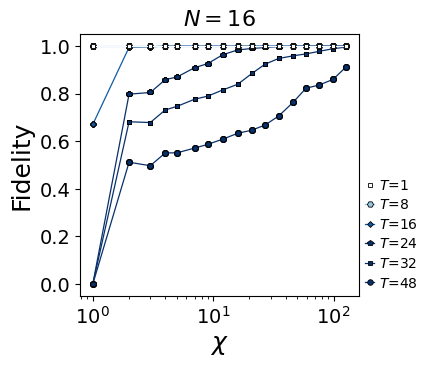

In [ ]:
FF = 1
L = 16
cutoff = 1500
data = data_fid
data_x = data_bonds
plt.rcParams.update({'font.size': 14}) 
    
fig,ax1=plt.subplots()

csize=3
msize=4
lwi=1.1
iw=0


sty=['H','D','p','s-','o-','H-','D-','p-','s-']
msi = [4,3,4,3,3,3,3,2,3,2,2,]  
iw=0


LWI=0.9
MSI=3

sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
iw=0

dat_y = data[L][np.float32(FF)]
dat_x = data_x[L][np.float32(FF)] 
for T in dat_y:
    if T>cutoff:
        continue
    dy = dat_y[T]
    dx = dat_x[1]
    xtab = []
    ytab = []
    for r in range(len(dy)): 
        xtab.append(dx[r])
        ytab.append(dy[r])

    ytab= np.array(ytab)
    xtab= np.array(xtab)
    SAT = L-(2*L-1)*L/(2**L+1)
    #print(SAT, ytab[L-2])
    colormap = cm.Blues
    normalize = mcolors.Normalize(vmin=1, vmax=19)
    CLR=colormap( normalize( T ) )
    plt.plot(xtab, ytab ,sty[iw], color=CLR,markersize=msi[iw],
                    markeredgewidth=.6, markeredgecolor='black', label='$T$='+str(T),
                    linewidth=LWI, zorder=100-iw)
    iw+=1
    
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    # axes.set_ylim([-0.05,1.1])

    #plt.yscale('log')
    plt.xscale('log')
    plt.title(r'$N=$' +str(L), fontsize=16)
    
    # plt.plot([0,1],[0,0],'--', color='red')
    # plt.plot([1,2],[0,1],'--', color='red')
    # plt.plot([2,3],[1,1],'--', color='red')


    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=10,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$\chi$",fontsize=18)
    plt.ylabel(r"Fidelity",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    if save:
        fig.savefig("plots/"+str(L)+"fidelities.pdf", bbox_inches='tight', transparent=True )

plt.show()

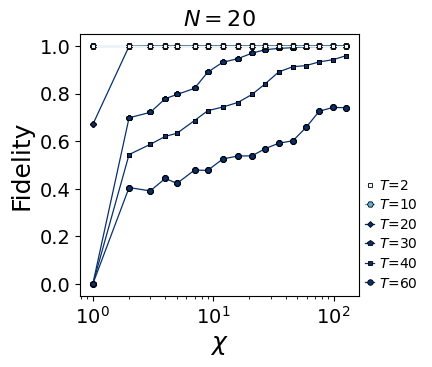

In [ ]:
FF = 1
L = 20
cutoff = 1500
data = data_fid
data_x = data_bonds
plt.rcParams.update({'font.size': 14}) 
    
fig,ax1=plt.subplots()

csize=3
msize=4
lwi=1.1
iw=0


sty=['H','D','p','s-','o-','H-','D-','p-','s-']
msi = [4,3,4,3,3,3,3,2,3,2,2,]  
iw=0


LWI=0.9
MSI=3

sty=['s-','H-','D-','p-','s-','o-','H-','D-','p-','s-']
msi = [3.5, 4.4,3.,4,3.5,4,4,3.5,3,2,3,2,2,]  
iw=0

dat_y = data[L][np.float32(FF)]
dat_x = data_x[L][np.float32(FF)] 
for T in dat_y:
    if T>cutoff:
        continue
    dy = dat_y[T]
    dx = dat_x[2]
    xtab = []
    ytab = []
    for r in range(len(dy)): 
        xtab.append(dx[r])
        ytab.append(dy[r])

    ytab= np.array(ytab)
    xtab= np.array(xtab)
    SAT = L-(2*L-1)*L/(2**L+1)
    #print(SAT, ytab[L-2])
    colormap = cm.Blues
    normalize = mcolors.Normalize(vmin=1, vmax=19)
    CLR=colormap( normalize( T ) )
    plt.plot(xtab, ytab ,sty[iw], color=CLR,markersize=msi[iw],
                    markeredgewidth=.6, markeredgecolor='black', label='$T$='+str(T),
                    linewidth=LWI, zorder=100-iw)
    iw+=1
    
    axes=plt.gca()
    #axes.set_xlim([1.7,2e4])
    # axes.set_ylim([-0.05,1.1])

    #plt.yscale('log')
    plt.xscale('log')
    plt.title(r'$N=$' +str(L), fontsize=16)
    
    # plt.plot([0,1],[0,0],'--', color='red')
    # plt.plot([1,2],[0,1],'--', color='red')
    # plt.plot([2,3],[1,1],'--', color='red')


    #xs=np.linspace(0,100,100)
    #plt.plot(xs, 3*(2)**xs,'--', color='red', zorder=2, linewidth=1)
    #plt.plot(xs, xs*0+np.log(2),'--', color='black')
    plt.legend(loc=(1,0),handlelength=0.7, frameon=False,fontsize=10,ncol=1, markerscale=1,labelspacing=0.4,columnspacing=0.2,handletextpad=0.3)
    

    
    #axes.set_yticks([0.38,0.43,0.48,0.53])
    #plt.plot([0.5,12], [0.52, 0.52],'--', color='red')
    #axes.set_yticks([1e-3,1e-2,1e-1,1e0,1e1,1e2,1e3])
    #axes.set_xticks([1e0,1e1,1e2,1e3,1e4])
    #plt.locator_params(axis='x', nbins=12)
    #plt.grid()
    
    plt.xlabel(r"$\chi$",fontsize=18)
    plt.ylabel(r"Fidelity",fontsize=18)
    
    fig.set_size_inches(3.6,3.4, forward=True)   
    
    if save:
        fig.savefig("plots/"+str(L)+"fidelities.pdf", bbox_inches='tight', transparent=True )

plt.show()